[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TARPS-group/prob-pipe/blob/main/docs/tutorials/getting_started.ipynb)

# Getting Started: Bayesian Workflow with ProbPipe

Most probabilistic workflows can be described mathematically in terms of distributions, fixed values, and a few operations (condition, marginalize, sample, push forward, differentiate, ...). However, implementing these analyses is more complex, for two reasons:

1. **Algorithmic.** Many algorithms can implement the same operation (NUTS, HMC, variational inference, SMC, ABC). Each has different trade-offs, lives in a different package, and expects its own input format.
2. **Representational.** Algorithms require and emit specific formats for both distributions and fixed values. An MCMC posterior is a set of samples; the next inference step wants a continuous density. Fixed values may be named parameter vectors, covariate matrices, or structured observations. Some frameworks rely on numpy or xarray, while others use JAX. 

As a result of these implementation complexities, users end up developing bespoke glue that is fragile and rarely scalable. ProbPipe's approach to solving these challenges is **simplification via abstraction**. Three core types, together with a small vocabulary of operations:

- **`Distribution`** is the universal representation of random quantities (priors, posteriors, likelihoods, data-generating processes). Each distribution declares its capabilities through `@runtime_checkable` protocols (`SupportsSampling`, `SupportsLogProb`, `SupportsMean`, `SupportsConditioning`, ...). Algorithms dispatch on those protocols rather than on concrete types, so TFP, scipy, and user-defined distributions participate on equal footing, and ProbPipe converts between representations as needed.
- **`Record`** is the deterministic counterpart: a named, structured container for fixed values (observed datasets, hyperparameters, design matrices). `Record` and `Distribution` share named-field access (`fields`, `select(...)`, `select_all()`) for splatting components into a workflow function, so they are interchangeable at call sites.
- **`WorkflowFunction`** is any function decorated with `@workflow_function`. Pass concrete values and it runs normally; pass a `Distribution` where a concrete value is expected and ProbPipe broadcasts over samples and returns the pushforward distribution, preserving correlation between jointly-sampled inputs.

With objects of these three types, ProbPipe lets you express probabilistic pipelines using a functional style that resembles mathematical manipulations, without directly managing the underlying implementation unless you want to.
A small set of **ops** covers most analyses: `condition_on` (compute a posterior distribution by dispatching to a registered inference method), `sample` / `log_prob` (uniform interfaces to draws and log densities), `mean` / `variance` / `cov` / `expectation` (distributional summaries with Monte Carlo fallback), `from_distribution` (convert between representations), and `predictive_check` (prior and posterior predictive checking). All of them accept distributions and records, and they hide the algorithmic choices behind the protocol registry so the call site reads the same whether the underlying engine is NUTS, nutpie, PyMC ADVI, or SMC-ABC. 


### Iterative Bayesian workflow

The benefits of ProbPipe are nicely illustrated when you need to revise an analysis pipeline many times. Applied Bayesian analysis is iterative: start simple, check the model against data, revise, and repeat (see [Gelman et al. 2020, *Bayesian Workflow*](https://arxiv.org/abs/2011.01808)). Each iteration follows the same steps: prior predictive check, fit, computational diagnostics, posterior predictive check, then decide what to change and repeat as needed. Across iterations you may need to try different likelihood models, swap inference algorithms, or feed posteriors into downstream predictions. This tutorial walks through an example of this process where the obvious first model fails its posterior predictive checks and we revise it. Later sections present tools you might need on more challenging problems.

In [ ]:
# Colab setup — installs ProbPipe (plus the extras this tutorial uses) and
# fetches the dataset. Runs only on Google Colab; on local Jupyter, the docs
# build, and CI this block is skipped, so it never affects execution elsewhere.
try:
    import google.colab  # noqa: F401
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

if _IN_COLAB:
    import os, subprocess, sys, urllib.request

    subprocess.run(
        [sys.executable, "-m", "pip", "install",
         "probpipe-core[viz,pymc,nutpie] @ git+https://github.com/TARPS-group/prob-pipe@main"],
        check=True,
    )
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/TARPS-group/prob-pipe/main/"
        "docs/tutorials/data/horseshoe_crabs.csv",
        "data/horseshoe_crabs.csv",
    )

## 1. Running example: modeling count data

To illustrate ProbPipe's features, we analyze the **horseshoe crab satellite** dataset (Brockmann, 1996; Agresti, 2007). Each nesting female horseshoe crab may attract "satellite" males. The response is the **count of satellites**, with the female's **carapace width** (cm) as the primary covariate.

In [1]:
import warnings
warnings.filterwarnings('ignore', message=r'Explicitly requested dtype.*float64.*')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import jax, jax.numpy as jnp, numpy as np, matplotlib.pyplot as plt
import pandas as pd
import tensorflow_probability.substrates.jax.glm as tfp_glm

from probpipe import (
    Record, NumericRecordArray, NumericEventTemplate, Normal, ProductDistribution,
    EmpiricalDistribution, BootstrapReplicateDistribution,
    GLMLikelihood, SimpleModel,
    condition_on, mean, variance,
    workflow_function, predictive_check, provenance_ancestors,
)
from probpipe.modeling import IncrementalConditioner
from probpipe.custom_types import ArrayLike

The first step is to load the data as usual (we use pandas), then standardize the covariates. Standardization is doing using a workflow function. This considerd ProbPipe best practice to ensure scalability and full traceability thanks to built-in provenance tracking. 

In [2]:
df = pd.read_csv("data/horseshoe_crabs.csv")
print(df)

     width_cm  satellites
0        28.3           8
1        22.5           0
2        26.0           9
3        24.8           0
4        26.0           4
..        ...         ...
167      32.5           0
168      23.5           0
169      26.5           6
170      25.5           3
171      22.5           1

[172 rows x 2 columns]


In [3]:
# Standardize the covariate and assemble (X, y). For a single
# covariate the natural form is a 1-D X array; GLMLikelihood
# (``fit_intercept=True`` default) adds the intercept as its
# own parameter, and the PyMC model in section 11 uses an
# explicit ``intercept`` RV. Returning a NumericRecordArray
# names the structure for what it is — a batch of N
# observations with named scalar fields X and y.
x_mean = float(df['width_cm'].mean())
x_std = float(df['width_cm'].std())

@workflow_function
def prep_data(width: ArrayLike, satellites: ArrayLike) -> NumericRecordArray:
    width = np.asarray(width, dtype=np.float32)
    width_z = ((width - np.mean(width)) / np.std(width)).astype(np.float32)
    y = np.asarray(satellites, dtype=np.float32)
    template = NumericEventTemplate(X=(), y=())
    return NumericRecordArray(
        {'X': width_z, 'y': y}, batch_shape=(len(width),), template=template,
    )


data = prep_data(df['width_cm'], df['satellites'])
print(data)
print(data.source)

NumericRecordArray(batch_shape=(172,), X=array(shape=(172,)), y=array(shape=(172,)))
Provenance('workflow.prep_data', parents=[])


## 2. Choose an initial model

We start simple: a **Poisson regression** for count data, $y_i \sim \mathrm{Poisson}(\exp(\boldsymbol{x}_i^\top \boldsymbol{\beta}))$.

`GLMLikelihood` wraps a TFP generalized linear model (GLM) family and a design matrix into a ProbPipe likelihood that supports both inference and data generation. Models can also be defined using PyMC, Stan, or TFP directly (see §11).

In [4]:
lik_poisson = GLMLikelihood(tfp_glm.Poisson(), data["X"])
# Named prior — posterior draws carry 'intercept'/'slope' fields,
# read by name as draws['intercept'], draws['slope']
prior = ProductDistribution(Normal(loc=0.0, scale=jnp.sqrt(5.0), name="intercept"),
                            Normal(loc=0.0, scale=jnp.sqrt(5.0), name="slope"))
model_poisson = SimpleModel(prior, lik_poisson, name='poisson')

## 3. Prior predictive checking

A prior is a statement about which datasets you consider plausible *before* seeing the data. If the prior implies wildly unrealistic data, the posterior starts from the wrong place and inference will struggle. `predictive_check` draws parameters from the prior, generates replicated data through the likelihood, and computes a summary statistic you choose. Without `observed_data` it acts as a **prior predictive check**; with `observed_data` the same call becomes a posterior predictive check (we use that mode in §6).

In [5]:
prior_check = predictive_check(prior, lik_poisson, test_fn=jnp.mean,
                               num_observations=len(data["y"]))
prior_means = np.array(prior_check['replicated_statistics'].samples)
print(f'Prior predictive mean: median={np.median(prior_means):.1f}, '
      f'90th pct={np.percentile(prior_means, 90):.1f}')
print(f'Observed mean: {data["y"].mean():.2f}')

Prior predictive mean: median=5.7, 90th pct=1003.7
Observed mean: 2.34


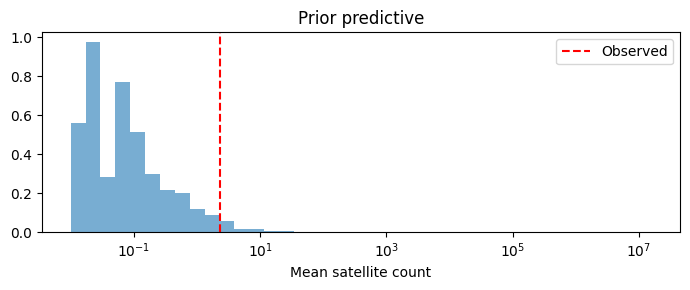

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
bins = np.logspace(np.log10(max(prior_means.min(), 0.01)),
                   np.log10(prior_means.max()), 40)
ax.hist(prior_means, bins=bins, density=True, alpha=0.6)
ax.axvline(float(data["y"].mean()), color='red', ls='--', label='Observed')
ax.set(xlabel='Mean satellite count', title='Prior predictive')
ax.set_xscale('log'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Fit the model

`condition_on` runs MCMC via the **inference method registry**, which auto-selects the best available algorithm: the No-U-Turn Sampler (NUTS, BlackJAX-backed by default) when the log-density is JAX-traceable, and gradient-free random-walk Metropolis–Hastings (RWMH) otherwise. Pass `method="blackjax_hmc"` (or any registered name) to override. The result is an `ApproximateDistribution` with chain structure and diagnostics.

In [7]:
posterior_poisson = condition_on(model_poisson, data["y"])
print(f'Posterior mean: {mean(posterior_poisson)}')

Posterior mean: NumericRecord(intercept=Array(0.6584339, dtype=float32), slope=Array(0.6034325, dtype=float32))


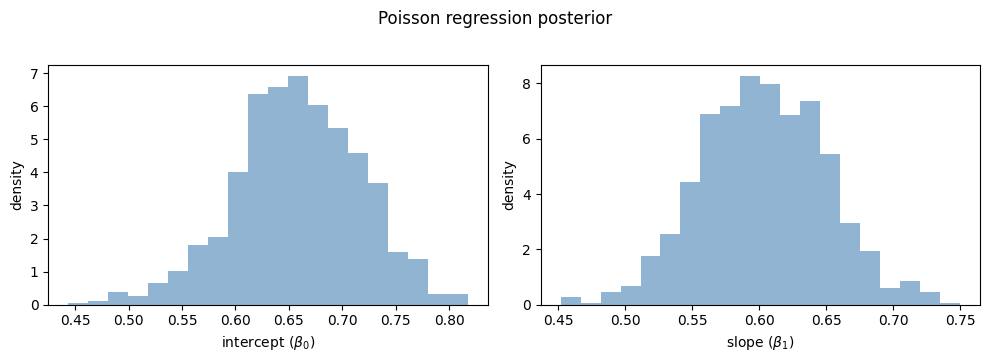

In [8]:
draws = posterior_poisson.draws()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, name in zip(axes, ['intercept', 'slope']):
    label = f'{name} ($\\beta_0$)' if name == 'intercept' else f'{name} ($\\beta_1$)'
    ax.hist(np.asarray(draws[name]), bins=20, density=True, alpha=0.6, color='steelblue')
    ax.set(xlabel=label, ylabel="density")
plt.suptitle('Poisson regression posterior', y=1.02)
plt.tight_layout(); plt.show()

## 5. Provenance tracking

Every distribution records how it was created: the algorithm, the parent distributions, and any associated metadata. This enables full lineage tracing from any result back to its inputs.

In [9]:
print(posterior_poisson.source)

Provenance('blackjax_nuts', parents=[product(intercept,slope)])


## 6. Posterior predictive checking

Does the fitted model reproduce key features of the data? With `observed_data`, `predictive_check` also returns a calibration **p-value**. We check two statistics: the **variance-to-mean ratio** (a standard overdispersion diagnostic for count data) and the **fraction of zeros**.

In [10]:
var_mean_ratio = lambda d: float(jnp.var(d) / jnp.maximum(jnp.mean(d), 1e-6))
zero_fraction = lambda d: float(jnp.mean(d == 0))

ppc_vmr = predictive_check(posterior_poisson, lik_poisson, var_mean_ratio, observed_data=data["y"])
ppc_zeros = predictive_check(posterior_poisson, lik_poisson, zero_fraction, observed_data=data["y"])

print(f"Var/mean ratio — observed: {ppc_vmr['observed_statistic']:.2f}, p={ppc_vmr['p_value']:.3f}")
print(f"Zero fraction  — observed: {ppc_zeros['observed_statistic']:.2f}, "
      f"p={ppc_zeros['p_value']:.3f}")

Var/mean ratio — observed: 4.14, p=0.000
Zero fraction  — observed: 0.47, p=0.000


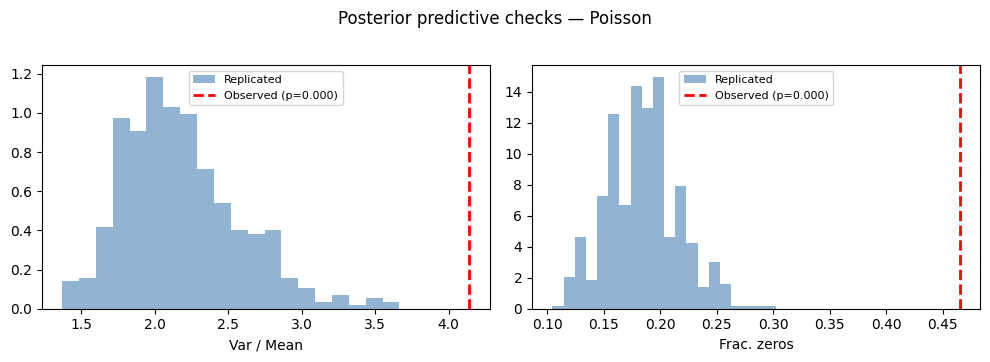

In [11]:
def plot_ppc(checks, labels, title):
    fig, axes = plt.subplots(1, len(checks), figsize=(5 * len(checks), 3.5))
    for ax, check, label in zip(axes, checks, labels):
        ax.hist(np.array(check['replicated_statistics'].samples), bins=20,
                density=True, alpha=0.6, color='steelblue', label='Replicated')
        ax.axvline(check['observed_statistic'], color='red', ls='--', lw=2,
                   label=f"Observed (p={check['p_value']:.3f})")
        ax.set(xlabel=label); ax.legend(fontsize=8)
    plt.suptitle(title, y=1.02)
    plt.tight_layout(); plt.show()

plot_ppc([ppc_vmr, ppc_zeros], ['Var / Mean', 'Frac. zeros'],
         'Posterior predictive checks — Poisson')

Both checks **fail**: the Poisson model cannot reproduce the overdispersion or the excess zeros in the observed data. This motivates revising the model.

## 7. Revise and compare models

The **negative binomial** naturally handles overdispersion. With `GLMLikelihood`, swapping is a one-line change: just replace the TFP family.

In [12]:
lik_nb = GLMLikelihood(tfp_glm.NegativeBinomial(), data["X"])
# Named prior — posterior draws carry 'intercept'/'slope' fields,
# read by name as draws['intercept'], draws['slope']
prior_nb = ProductDistribution(Normal(loc=0.0, scale=jnp.sqrt(5.0), name="intercept"),
                               Normal(loc=0.0, scale=jnp.sqrt(5.0), name="slope"))
model_nb = SimpleModel(prior_nb, lik_nb, name='negbin')

posterior_nb = condition_on(model_nb, data["y"])
print(f'NegBin posterior mean: {mean(posterior_nb)}')

NegBin posterior mean: NumericRecord(intercept=Array(0.55128115, dtype=float32), slope=Array(0.89175206, dtype=float32))


Var/mean ratio — p=0.964 (was 0.000 for Poisson)
Zero fraction  — p=0.024 (was 0.000 for Poisson)


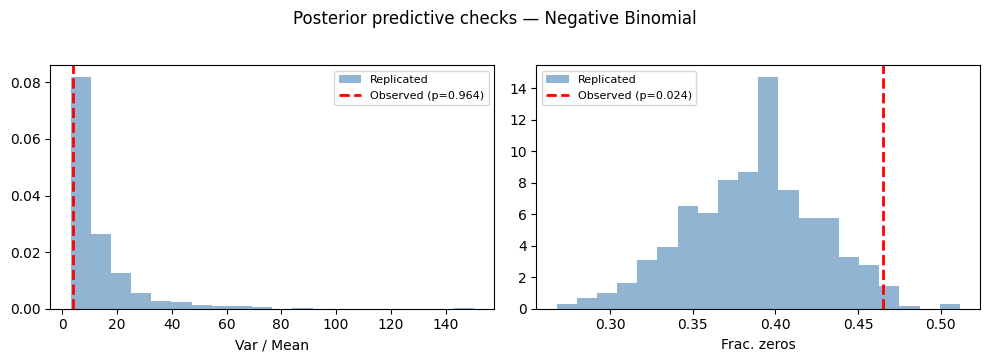

In [13]:
ppc_nb_vmr = predictive_check(posterior_nb, lik_nb, var_mean_ratio, observed_data=data["y"])
ppc_nb_zeros = predictive_check(posterior_nb, lik_nb, zero_fraction, observed_data=data["y"])

print(f"Var/mean ratio — p={ppc_nb_vmr['p_value']:.3f} (was {ppc_vmr['p_value']:.3f} for Poisson)")
print(f"Zero fraction  — p={ppc_nb_zeros['p_value']:.3f} "
      f"(was {ppc_zeros['p_value']:.3f} for Poisson)")

plot_ppc([ppc_nb_vmr, ppc_nb_zeros], ['Var / Mean', 'Frac. zeros'],
         'Posterior predictive checks — Negative Binomial')

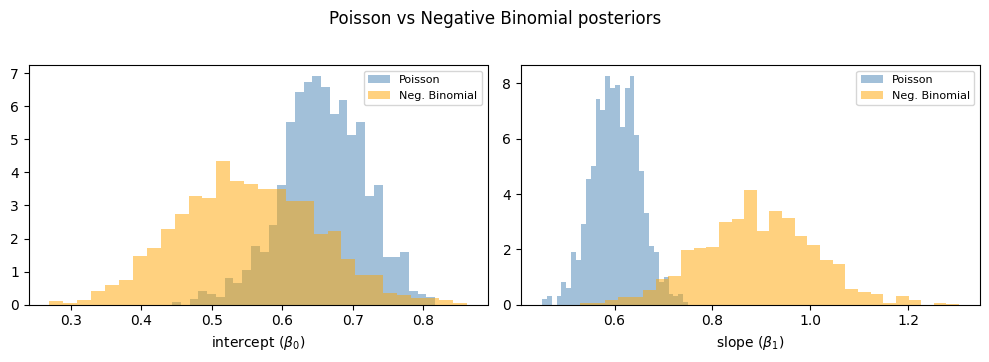

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, name in zip(axes, ['intercept', 'slope']):
    label = f'{name} ($\\beta_0$)' if name == 'intercept' else f'{name} ($\\beta_1$)'
    ax.hist(np.asarray(posterior_poisson.draws()[name]), bins=30, density=True,
            alpha=0.5, color='steelblue', label='Poisson')
    ax.hist(np.asarray(posterior_nb.draws()[name]), bins=30, density=True,
            alpha=0.5, color='orange', label='Neg. Binomial')
    ax.set(xlabel=label); ax.legend(fontsize=8)
plt.suptitle('Poisson vs Negative Binomial posteriors', y=1.02)
plt.tight_layout(); plt.show()

The negative binomial posteriors are wider and shifted, reflecting greater uncertainty once overdispersion is accounted for. Misspecification appears to have biased the Poisson posteriors toward narrow, overconfident estimates.

## 8. Bagged posteriors

The negative binomial fits our data, but we don't always end up with a model that passes every check. Under model misspecification, standard posteriors can be unreliable: credible sets from different datasets may not overlap. The **bagged posterior** (Huggins & Miller, 2024) averages over posteriors conditioned on bootstrapped datasets, yielding reproducible uncertainty quantification. Below we stress-test both the Poisson and negative binomial fits to see which one is stable under resampling.

`BootstrapReplicateDistribution` wraps data as a distribution over bootstrap datasets. When `data` is a `Record` (with named fields like `X` and `y`), rows are resampled **jointly** across all fields, preserving the per-observation relationship between covariates and response. Named field access (`bootstrap["X"]`, `bootstrap["y"]`) returns distribution views that, when passed to `condition_on` as named kwargs, are **sampled jointly** from the same parent so correlation is preserved automatically.

We use `condition_on.with_options(n_broadcast_samples=...)` to control the number of bootstrap replicates and `dispatch="thread"` to run MCMC fits concurrently. (For even greater scalability, ProbPipe supports Prefect orchestration to distribute fits across machines.)

If the individual posteriors across bootstrapped datasets are tightly clustered, the model is stable. If they spread apart, the model is sensitive to which rows happen to be in the dataset, a sign of misspecification.

In [15]:
# Record-native bootstrap: rows are resampled jointly across X and y
bootstrap = BootstrapReplicateDistribution(EmpiricalDistribution(data))

# bootstrap["X"] and bootstrap["y"] are distribution views from the same parent,
# so condition_on samples them jointly — preserving row correspondence.
bagged_poisson = condition_on.with_options(n_broadcast_samples=32)(
    model_poisson, X=bootstrap["X"], y=bootstrap["y"], dispatch="thread"
)
bagged_nb = condition_on.with_options(n_broadcast_samples=16)(
    model_nb, X=bootstrap["X"], y=bootstrap["y"], dispatch="thread"
)

In [16]:
# Sampling variability ratio: Var(individual means) / Var(bagged posterior).
# As a rough guide, ratios well above ~0.5 flag unstable, likely-misspecified inference.
for label, bagged in [('Poisson', bagged_poisson), ('NegBin', bagged_nb)]:
    ind_means = np.array([mean(p).flatten() for p in bagged.components])
    # Pool draws from all component posteriors
    all_draws = np.concatenate([np.asarray(p.draws().flatten()) for p in bagged.components])
    ratio = np.var(ind_means, axis=0) / np.var(all_draws, axis=0)
    print(f'{label}: sampling variability ratio = {np.array2string(ratio, precision=3)}')

Poisson: sampling variability ratio = [0.686 0.857]
NegBin: sampling variability ratio = [0.543 0.318]


The sampling variability ratios for the Poisson model are well above 0.5, indicating misspecification and instability. For the negative binomial the ratios are markedly lower — slope 0.318 well below 0.5, intercept 0.543 near the threshold — indicating substantially improved stability over the Poisson fit.

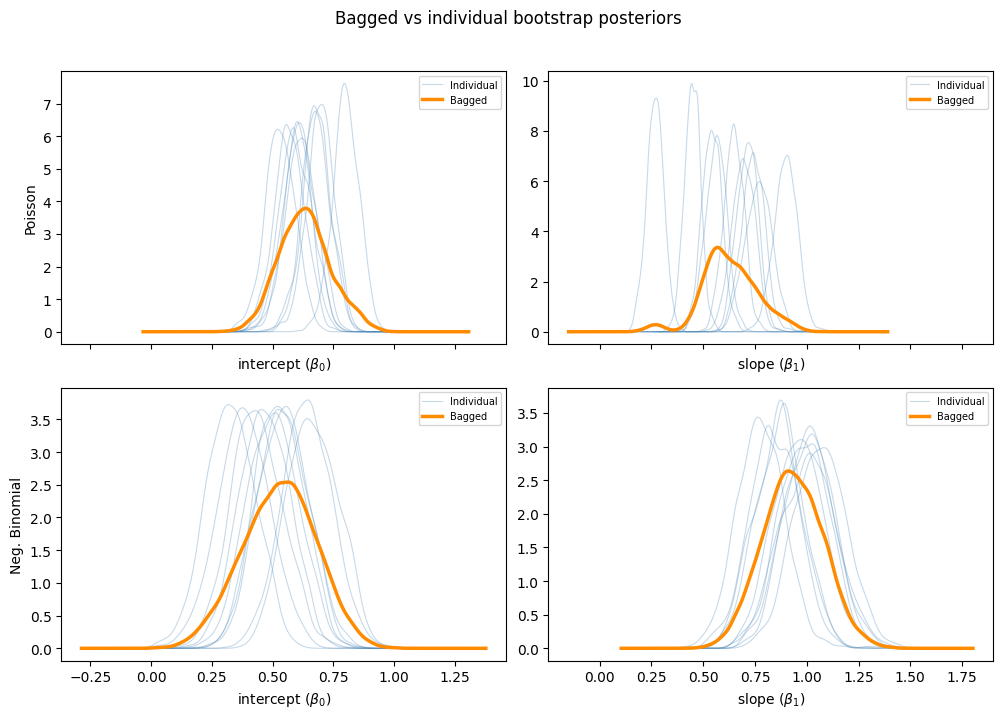

In [17]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex='col')

for row, (bagged, label) in enumerate([(bagged_poisson, 'Poisson'), (bagged_nb, 'Neg. Binomial')]):
    for col, name in enumerate(['intercept', 'slope']):
        param_label = f'{name} ($\\beta_0$)' if name == 'intercept' else f'{name} ($\\beta_1$)'
        ax = axes[row, col]
        # Individual bootstrap posteriors
        for i, post in enumerate(bagged.components[:10]):
            d = np.asarray(post.draws()[name])
            xs = np.linspace(d.min() - 0.3, d.max() + 0.3, 200)
            ax.plot(xs, gaussian_kde(d)(xs), alpha=0.3, lw=0.8, color='steelblue',
                    label='Individual' if i == 0 else None)
        # Bagged posterior: pool draws from all components
        bd = np.concatenate([np.asarray(p.draws()[name]) for p in bagged.components])
        xs = np.linspace(bd.min() - 0.3, bd.max() + 0.3, 200)
        ax.plot(xs, gaussian_kde(bd)(xs), color='darkorange', lw=2.5, label='Bagged')
        ax.set(xlabel=param_label); ax.legend(fontsize=7)
        if col == 0:
            ax.set_ylabel(label)

plt.suptitle('Bagged vs individual bootstrap posteriors', y=1.02)
plt.tight_layout(); plt.show()

The Poisson individual posteriors spread apart noticeably, and the Poisson bagged posterior for the slope captures the range of plausible values under the negative binomial model. The negative binomial individual posteriors are more tightly clustered, consistent with a better-specified model.

## 9. Sequential updating

Data often arrives in batches. `IncrementalConditioner` chains posterior updates across those batches, turning each new posterior into the prior for the next round. It automatically converts the MCMC posterior to a smooth KDE before the handoff (NUTS needs a continuous density). Pass each batch's data fields as named kwargs; the same conditioner handles all updates.

In [18]:
X, y = np.asarray(data["X"], dtype=np.float32), np.asarray(data["y"], dtype=np.float32)
n = len(y)
batch_ends = [40, 80, 130, n]
batches_X = [X[:batch_ends[0]]] + [X[s:e] for s, e in zip(batch_ends[:-1], batch_ends[1:])]
batches_y = [y[:batch_ends[0]]] + [y[s:e] for s, e in zip(batch_ends[:-1], batch_ends[1:])]

prior = ProductDistribution(Normal(loc=0.0, scale=jnp.sqrt(5.0), name="intercept"),
                    Normal(loc=0.0, scale=jnp.sqrt(5.0), name="slope"))

# One conditioner for all batches — pass data fields as named kwargs
conditioner = IncrementalConditioner(prior, GLMLikelihood(tfp_glm.NegativeBinomial()))

total = 0
for Xi, yi in zip(batches_X, batches_y):
    conditioner.update(X=Xi, y=yi)
    total += len(yi)
    print(f'n={total}: mean = {mean(conditioner.curr_posterior)}')

print(f'\nFull-data posterior mean: {mean(posterior_nb)}')

n=40: mean = NumericRecord(intercept=Array(0.782869, dtype=float32), slope=Array(0.91530514, dtype=float32))


n=80: mean = NumericRecord(intercept=Array(0.6788004, dtype=float32), slope=Array(0.86441153, dtype=float32))


n=130: mean = NumericRecord(intercept=Array(0.51428884, dtype=float32), slope=Array(0.9303026, dtype=float32))


n=172: mean = NumericRecord(intercept=Array(0.53039783, dtype=float32), slope=Array(0.88493264, dtype=float32))

Full-data posterior mean: NumericRecord(intercept=Array(0.55128115, dtype=float32), slope=Array(0.89175206, dtype=float32))


Provenance tracking is particularly valuable for sequential pipelines: the lineage traces back through each conditioning step, making the full chain of updates auditable.

In [19]:
ancestors = provenance_ancestors(conditioner.curr_posterior)
print(f'Sequential posterior ancestors: {[a.type_name for a in ancestors]}')

Sequential posterior ancestors: ['KDEDistribution', 'ApproximateDistribution', 'KDEDistribution', 'ApproximateDistribution', 'KDEDistribution', 'ApproximateDistribution', 'ProductDistribution']


## 10. Propagate uncertainty

`predictive_check` and `condition_on` already showed ProbPipe broadcasting a function over a distribution automatically. The same mechanism applies to any `@workflow_function`: pass in a posterior where a concrete value is expected, and the output is a distribution over results.

In [20]:
@workflow_function
def predict_rate(intercept, slope, x):
    return jnp.exp(intercept + slope * x)

rate_dist = predict_rate(**posterior_nb.select_all(), x=0.0)
print(f'Rate at mean width: {float(mean(rate_dist)):.2f} '
      f'(+/- {float(jnp.sqrt(variance(rate_dist))):.2f})')

Rate at mean width: 1.76 (+/- 0.16)


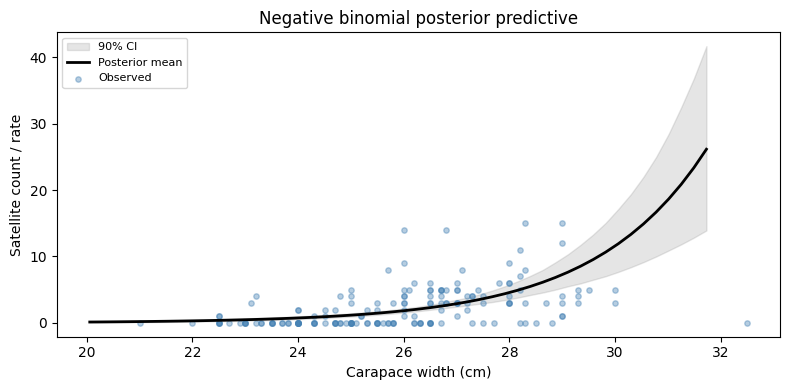

In [21]:
x_grid_z = jnp.linspace(-3, 3, 50)
x_grid_cm = np.array(x_grid_z) * x_std + x_mean

# Splatting ``posterior_nb.select_all()`` hands ``predict_rate`` two
# views over a single parent posterior, so ProbPipe samples them
# jointly (preserving correlation between intercept and slope) and
# returns a marginal distribution over rates at every x.
rates_dist = predict_rate.with_options(n_broadcast_samples=500)(
    **posterior_nb.select_all(),
    x=x_grid_z,
)
rates = np.asarray(rates_dist.samples)          # (n_draws, 50)
lo, hi = np.percentile(rates, [5, 95], axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(x_grid_cm, lo, hi, alpha=0.2, color='gray', label='90% CI')
ax.plot(x_grid_cm, rates.mean(axis=0), 'k-', lw=2, label='Posterior mean')
ax.scatter(df['width_cm'], np.asarray(data['y']), s=15, alpha=0.4,
           color='steelblue', label='Observed')
ax.set(xlabel='Carapace width (cm)', ylabel='Satellite count / rate',
       title='Negative binomial posterior predictive')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


## 11. Inference registry and external backends

Every call to `condition_on` is dispatched through a pluggable **inference method registry**. The registry ranks feasible methods by priority and auto-selects the best one; override with `method=`. Registered methods span MCMC algorithms (NUTS via BlackJAX by default; nutpie / CmdStan / PyMC for `StanModel` / `PyMCModel` targets; gradient-free RWMH; opt-in TFP NUTS / HMC and BlackJAX HMC), stochastic-gradient MCMC (BlackJAX SGLD / SGHMC), variational inference (opt-in PyMC ADVI).

In [22]:
from probpipe.inference import inference_method_registry

# List all registered inference methods (highest priority first)
inference_method_registry.list_methods()

['nutpie_nuts',
 'blackjax_nuts',
 'cmdstan_nuts',
 'pymc_nuts',
 'blackjax_elliptical_slice',
 'blackjax_rwmh',
 'blackjax_sgld',
 'tfp_nuts',
 'tfp_hmc',
 'blackjax_hmc',
 'blackjax_sghmc',
 'pymc_advi']

In [23]:
import warnings
warnings.filterwarnings('ignore', message=r'install "ipywidgets"')

import pymc as pm
from probpipe.modeling import PyMCModel

# Both X and y flow through as observed-named inputs so the
# WorkflowFunction layer's provenance tracking captures both as
# parents of the resulting posterior (rather than X sneaking in
# via closure capture, which would leave it off the lineage).
def poisson_model(X=None, y=None):
    if X is None:
        # Sentinel for the unconditioned build during
        # PyMCModel.__init__; replaced by real X at inference.
        X = np.ones(1, dtype=np.float32)
    with pm.Model() as m:
        intercept = pm.Normal('intercept', 0, np.sqrt(5.0))
        slope = pm.Normal('slope', 0, np.sqrt(5.0))
        rate = pm.math.exp(intercept + slope * X)
        pm.Poisson('y', mu=rate, observed=y)
    return m

posterior_pymc = condition_on(PyMCModel(poisson_model), data)
print(f'PyMC posterior mean: {mean(posterior_pymc)}')

Output()

PyMC posterior mean: NumericRecord(intercept=Array(0.660641, dtype=float32), slope=Array(0.60260427, dtype=float32))


### Stochastic-gradient MCMC for large datasets

When the dataset is large enough that evaluating the full-data log-density per step is expensive, the registry includes BlackJAX-backed **stochastic-gradient MCMC** kernels: `blackjax_sgld` (Stochastic Gradient Langevin Dynamics) and `blackjax_sghmc` (its momentum-augmented sibling). Both estimate the posterior gradient from a random minibatch each step, with the standard $N/b$ rescaling so the gradient is unbiased.

Their priorities sit in the refinement-based MC tier below the full-batch gradient methods, and their `check()` requires:

- A `SimpleModel` whose likelihood satisfies `ConditionallyIndependentLikelihood` (`GLMLikelihood` already does — every supported family factorises across observations).
- A `Record(X=..., y=...)` for `observed` so the kernel can slice minibatches along the leading axis.
- An explicit `batch_size=` (no canonical default for a stochastic sampler).

The crab dataset is small enough that full-batch NUTS is the right choice in practice, but it suffices to demonstrate the API:


In [24]:
# Stochastic Gradient Langevin Dynamics — opt in via method=.
# Pass `data` (a Record(X, y)) so the kernel can subsample observations.
posterior_sgld = condition_on(
    model_poisson, data,
    method="blackjax_sgld",
    batch_size=32, num_results=3000, num_warmup=1000,
    step_size=1e-4, random_seed=0,
)
print(f'SGLD posterior mean: {mean(posterior_sgld)}')

SGLD posterior mean: NumericRecord(intercept=Array(0.6446949, dtype=float32), slope=Array(0.5945295, dtype=float32))


### References

- Gelman, A., Vehtari, A., Simpson, D., et al. (2020). [Bayesian Workflow](https://arxiv.org/abs/2011.01808). *arXiv:2011.01808*.
- Brockmann, H.J. (1996). Satellite male groups in horseshoe crabs, *Limulus polyphemus*. *Ethology*, 102(1), 1–21.
- Huggins, J.H. & Miller, J.W. (2024). [Reproducible Model Selection Using Bagged Posteriors](https://doi.org/10.1214/24-EJS2237). *Electronic Journal of Statistics*, 18(2), 3709–3752.

## Next steps

- [**Flexible inference with `condition_on`**](flexible_inference.ipynb) — a second tutorial built around an ecological population model. The tractable case is fit with NUTS via `condition_on`, illustrating how ProbPipe's protocol-based dispatch lets you swap inference engines without rewriting the model. (Its simulation-based inference sections are being re-platformed onto new backends — see the note at the top of that notebook.)
- [**API Reference**](../api/distributions.md) — distributions, modeling primitives, inference methods, and the operation registry.
- [**User Guide**](../user_guide.md) — focused examples for individual features.